## Loading env and libaries

In [1]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

In [2]:
from dotenv import load_dotenv
import os
from pathlib import Path

def load_environment():
    """Load environment variables and return them as a dictionary."""
    load_dotenv(Path("../utils/.env"))  # Loads .env from project root (works if run from notebook too)
    env_vars = {
        "IMAGE_FOLDER": os.getenv("IMAGE_FOLDER"),
        "EXTRACTEDDATASET_FOLDER": os.getenv("EXTRACTEDDATASET_FOLDER"),
        "DATASETS_FOLDER": os.getenv("DATASETS_FOLDER"),
        "ElevationDataset": os.getenv("ElevationDataset"),
        "LandCoverDataset": os.getenv("LandCoverDataset"),
        "GeoBoundaries": os.getenv("GeoBoundaries"),
        "EXTRACTEDELEVATION_FOLDER": os.getenv("EXTRACTEDELEVATION_FOLDER"),
        "EXTRACTEDLANDCOVER_FOLDER": os.getenv("EXTRACTEDLANDCOVER_FOLDER"),
        "EXTRACTEDGEOBOUNDARIES_FOLDER": os.getenv("EXTRACTEDGEOBOUNDARIES_FOLDER")
    }
    return env_vars

folders = load_environment()
image_folder = folders["IMAGE_FOLDER"]
extractedData_folder = folders["EXTRACTEDDATASET_FOLDER"]
datasets_folder = folders["DATASETS_FOLDER"]
landCover_folder = folders["LandCoverDataset"]
elevation_folder = folders["ElevationDataset"]
geoboundaries_folder = folders["GeoBoundaries"]
extracted_elevation_folder = folders["EXTRACTEDELEVATION_FOLDER"]
extracted_landcover_folder = folders["EXTRACTEDLANDCOVER_FOLDER"]
extracted_geo_boundaries_folder = folders["EXTRACTEDGEOBOUNDARIES_FOLDER"]


## Read file

In [3]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Path to your extracted elevation raster
elev_path = os.path.join(extracted_elevation_folder, "elevation_dz_tn.tif")



In [4]:
# checking if there's any missing values
import rasterio
with rasterio.open(elev_path) as src:
    elevation_data = src.read(1)  # read the first band
    nodata_value = src.nodata
    missing_values_count = (elevation_data == nodata_value).sum()
    total_values_count = elevation_data.size
    print(f"Missing values: {missing_values_count} out of {total_values_count} ({(missing_values_count/total_values_count)*100:.2f}%)")
    print(f"Nodata value: {nodata_value}")

Missing values: 8989631 out of 22121099 (40.64%)
Nodata value: -32768.0


in the following , were going to mask this data --> probably sea levels


## Elevation summary

In [9]:
import rasterio
with rasterio.open(elev_path) as src:
    print("count",src.count)       # number of bands
    print("width: ",src.width,"height: " ,src.height)  # pixel dimensions
    print("crs: ",src.crs)         # coordinate reference system
    print("bounds:", src.bounds)      # geographic bounding box


count 1
width:  4961 height:  4459
crs:  EPSG:4326
bounds: BoundingBox(left=-8.67097222222236, bottom=18.96652777777771, right=11.99986111111096, top=37.545694444444365)


In [16]:
# display mean, med, and mode 
import numpy as np
with rasterio.open(elev_path) as src:
    elevation_data = src.read(1)  # read the first band
    mean_elev = np.mean(elevation_data[elevation_data != src.nodata])
    median_elev = np.median(elevation_data[elevation_data != src.nodata])
    mode_elev = pd.Series(elevation_data[elevation_data != src.nodata].flatten()).mode()[0]
    print(f"Mean Elevation: {mean_elev}")
    print(f"Median Elevation: {median_elev}")
    print(f"Mode Elevation: {mode_elev}")

Mean Elevation: 538.3276104392899
Median Elevation: 464.0
Mode Elevation: 301


## Elevation visualization

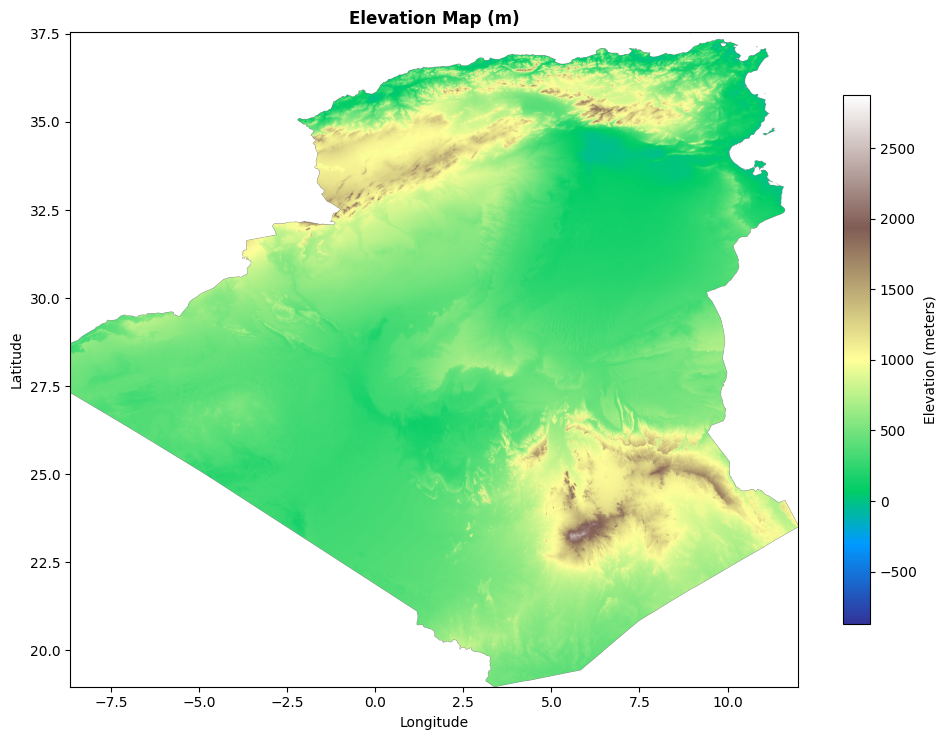

In [12]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

# --- Load and display elevation ---
with rasterio.open(elev_path) as src:
    fig, ax = plt.subplots(figsize=(10, 8))

    # Display raster
    img = show(src, ax=ax, cmap="terrain", title="Elevation Map (m)")

    # Add colorbar (elevation scale)
    cbar = plt.colorbar(img.get_images()[0], ax=ax, shrink=0.7)
    cbar.set_label("Elevation (meters)")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()


## Elevation distribution

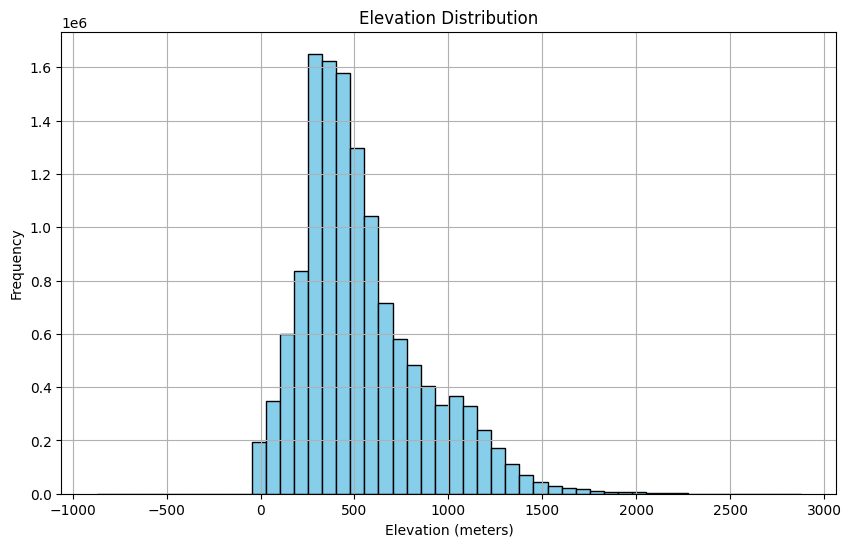

In [13]:
#  distribution of elevation values
import numpy as np
import matplotlib.pyplot as plt
with rasterio.open(elev_path) as src:
    elevation_data = src.read(1)  # read the first band

    # Mask no-data values
    elevation_data = np.ma.masked_equal(elevation_data, src.nodata)

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(elevation_data.compressed(), bins=50, color='skyblue', edgecolor='black')
    plt.title("Elevation Distribution")
    plt.xlabel("Elevation (meters)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

A mostly normal distribution with a slight left skew means:

most of your terrain is mid-to-high elevation (say, 800–1500 m),

with a few low-lying plains or coastal areas pulling the lower tail (the “left skew”).

That’s exactly what we’d expect for Algeria + Tunisia:

northern coastal and steppe regions are low (0–800 m),

southern areas gradually rise into the Saharan plateaus and mountains (1000–3000 m).

## Elevation Boxplot

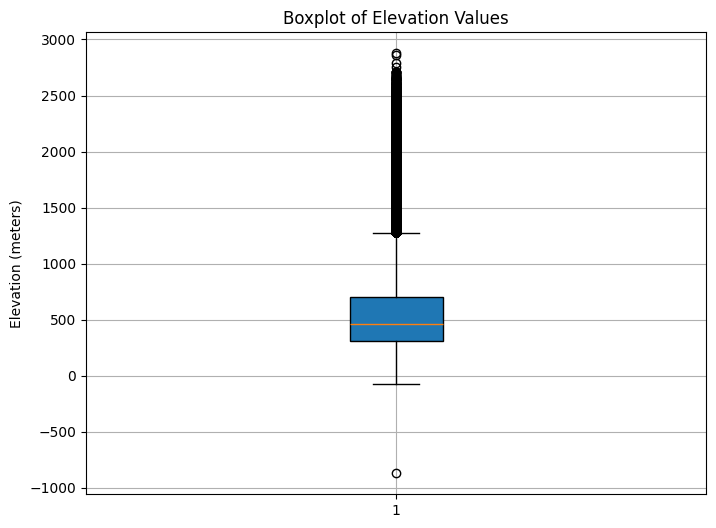

In [5]:
#  display a boxplot of elevation values
import matplotlib.pyplot as plt
with rasterio.open(elev_path) as src:
    elevation_data = src.read(1)  # read the first band

    # Mask no-data values
    elevation_data = elevation_data[elevation_data != src.nodata]

    # Plot boxplot
    plt.figure(figsize=(8, 6))
    plt.boxplot(elevation_data, vert=True, patch_artist=True)
    plt.title("Boxplot of Elevation Values")
    plt.ylabel("Elevation (meters)")
    plt.grid(True)
    plt.show()

The Tassili n’Ajjer and Hoggar mountains (Ahaggar) in southern Algeria reach up to 2900–3000 m — so that top range makes sense.